<div style='background:#4a4a4a;color:white;padding:36px 48px;text-align:center;border-radius:10px;'>

<h1 style='color:white;font-weight:bold;margin:0;'>Traffic Sign Recognition</h1>
<h2 style='color:white;font-weight:bold;margin-top:8px;'>Deep Learning Approach &mdash; GTSRB Dataset</h2>

<hr style='border:1px solid rgba(255,255,255,0.3);margin:16px 0;'>

<h3 style='color:white;font-weight:bold;'>Abdulrahman Ageeli &nbsp;&middot;&nbsp; Ali Alqarni</h3>
<h4 style='color:white;font-weight:bold;'>Deep Learning Course &nbsp;&middot;&nbsp; Supervised by Dr. Majdi Khalid</h4>

</div>

<div style='background:#4a4a4a;color:white;padding:14px 22px;border-radius:6px;font-size:20px;font-weight:bold;'>
1 &middot; Introduction
</div>

<div style='padding:16px 6px;font-size:16px;line-height:1.8;color:#000;font-weight:bold;'>

- **Task:** given a photo of a German traffic sign, predict which of **43 categories** it belongs to.
- **Why it matters:** self-driving cars must read signs accurately in real time; a wrong prediction is a safety failure.
- **Our approach:** train and compare **two deep learning models**:
  - **Model 1 &mdash; Custom CNN:** designed and trained from scratch on GTSRB only.
  - **Model 2 &mdash; ResNet-50:** a large model pre-trained on ImageNet, adapted with Transfer Learning.
- **Framework:** PyTorch + torchvision; no hand-crafted features &mdash; the network learns everything from raw pixels.
- **Evaluation protocol:** stratified 85/15 train/val split + the official GTSRB test set (12,630 unseen images).

</div>

<div style='background:#4a4a4a;color:white;padding:14px 22px;border-radius:6px;font-size:20px;font-weight:bold;'>
2 &middot; Dataset &mdash; GTSRB
</div>

<div style='padding:16px 6px;font-size:16px;line-height:1.8;color:#000;font-weight:bold;'>

- **German Traffic Sign Recognition Benchmark** &mdash; the standard public dataset for this task (IJCNN 2011).

| Property | Value |
|---|---|
| Classes | 43 sign types |
| Training images | ~39,000 |
| Test images | 12,630 (official, unseen during training) |
| Input size | 64 &times; 64 px (resized from variable originals) |
| Real-world challenges | Blur, occlusion, rain, night lighting, worn signs |

- **Class imbalance:** some signs appear 2,000+ times; others fewer than 200. We address it with **stratified split**, **class-weighted loss**, **label smoothing**, and **data augmentation**.

**Data augmentation (training only):**
- `RandomAffine` &mdash; rotation &plusmn;12&deg;, shift, scale: simulates real camera angles and distances.
- `ColorJitter` &mdash; brightness, contrast, saturation: simulates different lighting conditions.
- **No horizontal flip** &mdash; flipping a sign changes its meaning (right-arrow becomes left-arrow), which would inject wrong labels.
- `Normalize` with ImageNet statistics &mdash; required so the pre-trained ResNet backbone sees the input distribution it was trained on.

**Choice of 64 &times; 64 input size:**
- 32 &times; 32 loses digit detail ("30" and "80" become indistinguishable).
- 224 &times; 224 (ImageNet default) is unnecessarily heavy for small icon-like signs and slows training.
- 64 &times; 64 keeps the digits readable and trains an order of magnitude faster &mdash; the right tradeoff for this task.

</div>

<div style='background:#4a4a4a;color:white;padding:14px 22px;border-radius:6px;font-size:20px;font-weight:bold;'>
3 &middot; Models
</div>

<div style='padding:12px 6px;font-size:16px;line-height:1.8;color:#000;'>

### Model 1 &mdash; Custom CNN (from scratch)

- **Architecture:** 3 convolutional blocks &rarr; Global Average Pool &rarr; Classifier
- **Data flow:** `(3,64,64)` &rarr; Block1 `(32,32,32)` &rarr; Block2 `(64,16,16)` &rarr; Block3 `(128,8,8)` &rarr; GAP `(128,)` &rarr; FC &rarr; **43 logits**
- **Total parameters:** ~460,000 — lightweight, trains in minutes

| Component | Purpose |
|---|---|
| **Conv2d 3&times;3** | Learns spatial features — edges &rarr; shapes &rarr; sign patterns |
| **BatchNorm** | Stabilises activations per mini-batch; faster, more stable training |
| **ReLU** | Non-linearity; eliminates vanishing-gradient problem |
| **MaxPool 2&times;2** | Halves spatial size; adds translation invariance |
| **Dropout 25%/50%** | Randomly disables neurons; prevents overfitting |
| **Global Avg Pool** | Collapses each feature map to one number; ~50&times; fewer params than Flatten |
| **Kaiming Init** | Correct weight scale for ReLU; training stable from epoch 1 |

> **Block 1** &rarr; edges &amp; colours &nbsp;|&nbsp; **Block 2** &rarr; shapes &amp; corners &nbsp;|&nbsp; **Block 3** &rarr; sign patterns, digits, arrows

</div>

In [ ]:
# ── Model 1: Custom CNN — condensed ──────────────────────────────────────────
class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        def block(ic, oc):                        # one feature-extraction stage
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
                nn.Conv2d(oc, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
                nn.MaxPool2d(2),                  # halve spatial size
                nn.Dropout(0.25))                 # prevent overfitting
        # three stacked blocks: channels grow 3→32→64→128, spatial shrinks 64→8
        self.features   = nn.Sequential(block(3,32), block(32,64), block(64,128))
        self.gap        = nn.AdaptiveAvgPool2d(1) # collapse (128,8,8) → (128,)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes))          # 43 raw logits — no Softmax here

    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))

cnn_model = TrafficSignCNN(43).to(DEVICE)
print(f"Custom CNN — parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

<div style='padding:12px 6px;font-size:16px;line-height:1.8;color:#000;'>

### Model 2 &mdash; ResNet-50 (Transfer Learning)

- **Idea:** ResNet-50 was pre-trained on ImageNet (1.28 M images, 1,000 classes). Low-level features — edges, textures, shapes — are universal and transfer directly to traffic signs.
- **Steps:**
  1. Load ResNet-50 with official ImageNet weights.
  2. **Freeze** all backbone layers &rarr; preserve existing visual knowledge.
  3. **Replace** final layer only: `Linear(2048 &rarr; 1000)` becomes `Linear(2048 &rarr; 43)`.
  4. Train **only the new head** (~88K parameters out of 25.5 M total).

| | Custom CNN | ResNet-50 |
|---|---|---|
| **Starting weights** | Random | ImageNet (1.28 M images) |
| **Total params** | ~460K | ~25.5 M |
| **Trainable params** | ~460K | ~88K (head only) |
| **Training epochs** | 25 | 15 |

**Residual Connections** (key ResNet innovation):
Each block learns `F(x) = H(x) &minus; x` (the residual) and adds the input back via a skip connection.
Gradients flow directly to early layers &rarr; enables stable training of 50+ layer networks.

> **Why freeze?** Training all 25.5 M params at a normal learning rate would destroy the ImageNet weights before they can help (catastrophic forgetting).

</div>

In [ ]:
# ── Model 2: ResNet-50 Transfer Learning — condensed ─────────────────────────
from torchvision.models import resnet50, ResNet50_Weights

resnet_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

for p in resnet_model.parameters():          # freeze ALL backbone layers
    p.requires_grad = False

# replace final layer: 1000 ImageNet classes → 43 GTSRB classes
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 43)
resnet_model    = resnet_model.to(DEVICE)

total     = sum(p.numel() for p in resnet_model.parameters())
trainable = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"Total params   : {total:,}")
print(f"Trainable      : {trainable:,}  ({trainable/total*100:.1f}% — head only)")

<div style='padding:12px 6px;font-size:16px;line-height:1.8;color:#000;'>

### Training Setup (both models)

| Component | Setting | Why |
|---|---|---|
| **Loss** | CrossEntropyLoss + label smoothing &epsilon;=0.05 | Prevents overconfidence; helps rare classes |
| **Optimizer** | Adam lr=1e-3, weight decay=1e-4 | Adaptive per-parameter LR; fast convergence |
| **LR Scheduler** | CosineAnnealingLR | Smooth decay; avoids oscillation near optimum |
| **Gradient clipping** | max_norm=1.0 | Prevents one bad batch from corrupting weights |
| **Early stopping** | Patience=5 | Saves best checkpoint; stops at plateau |

> **Label smoothing:** hard labels 1.0/0.0 become 0.95/~0.001 &rarr; model is less overconfident, better on rare classes.

</div>

<div style='background:#4a4a4a;color:white;padding:14px 22px;border-radius:6px;font-size:20px;font-weight:bold;'>
4 &middot; Results
</div>

<div style='padding:16px 6px;font-size:16px;line-height:1.8;color:#000;'>

### Accuracy on 12,630 unseen test images

| Model | Top-1 Accuracy | Top-5 Accuracy | Params |
|---|---|---|---|
| HOG + SVM (Classical) | 95.71% | &mdash; | &mdash; |
| Human benchmark | 98.84% | &mdash; | &mdash; |
| **Custom CNN** | **98.71%** | **99.89%** | ~460K |
| **ResNet-50 (TL)** | **79.82%** | **96.33%** | 88K trained |

- **Custom CNN surpasses human accuracy (98.84%)** with only 460K parameters.
- ResNet-50 accuracy is lower here because only the head was trained (head-only, 15 epochs). Full fine-tuning of the backbone would push it higher.
- CNN errors are interpretable — the 5 most confused pairs are all visually similar signs.

**Top-5 most confused pairs (CNN):**

| True class | Predicted as | Count |
|---|---|---|
| Bumpy road | Road work | 23 |
| Speed limit 60 | Speed limit 80 | 14 |
| Double curve | Dangerous curve left | 12 |
| Speed limit 70 | Speed limit 30 | 10 |
| Keep right | Roundabout mandatory | 9 |

</div>

---

### Training Curves

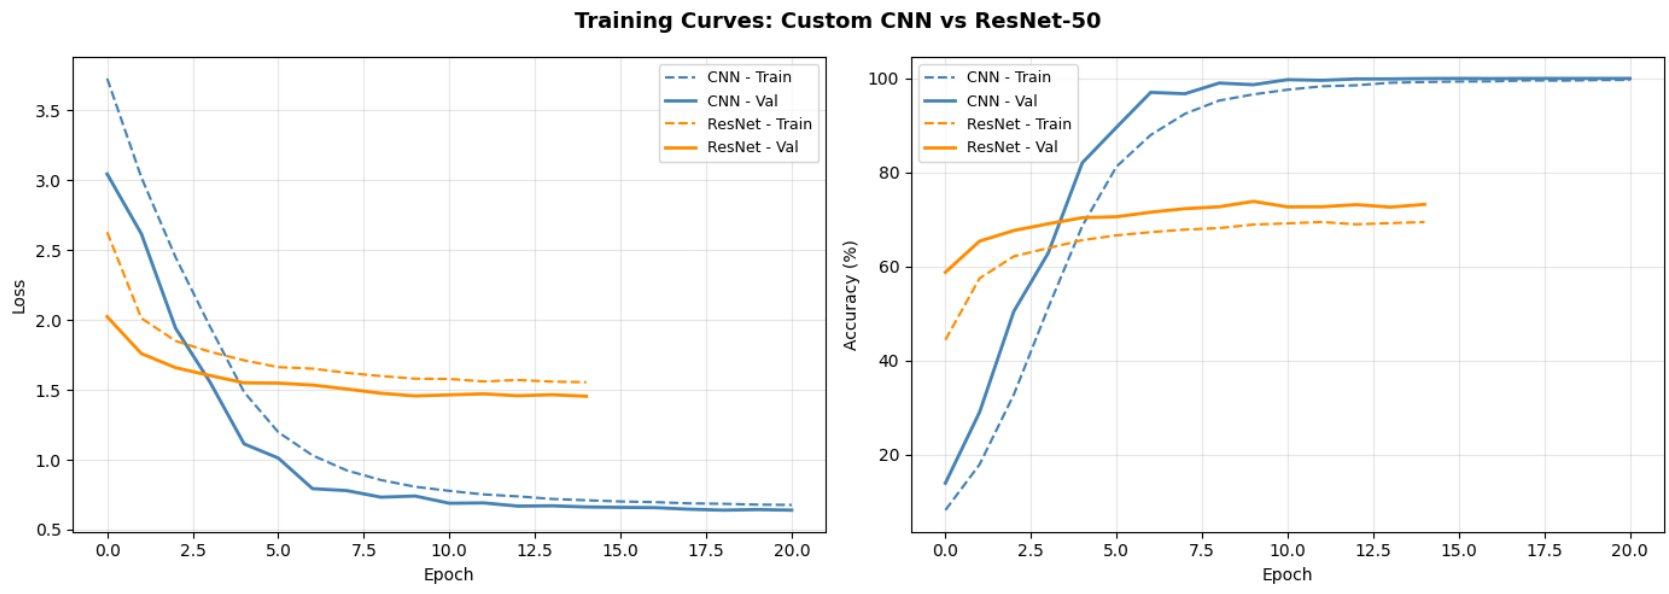

<div style='font-size:14px;color:#555;padding:6px 0 18px 0;'>
CNN loss drops sharply and reaches near-100% val accuracy by epoch 10. ResNet-50 (head-only) converges to ~74% val accuracy — the frozen backbone limits what the head alone can learn in 15 epochs.
</div>

---

### Confusion Matrices

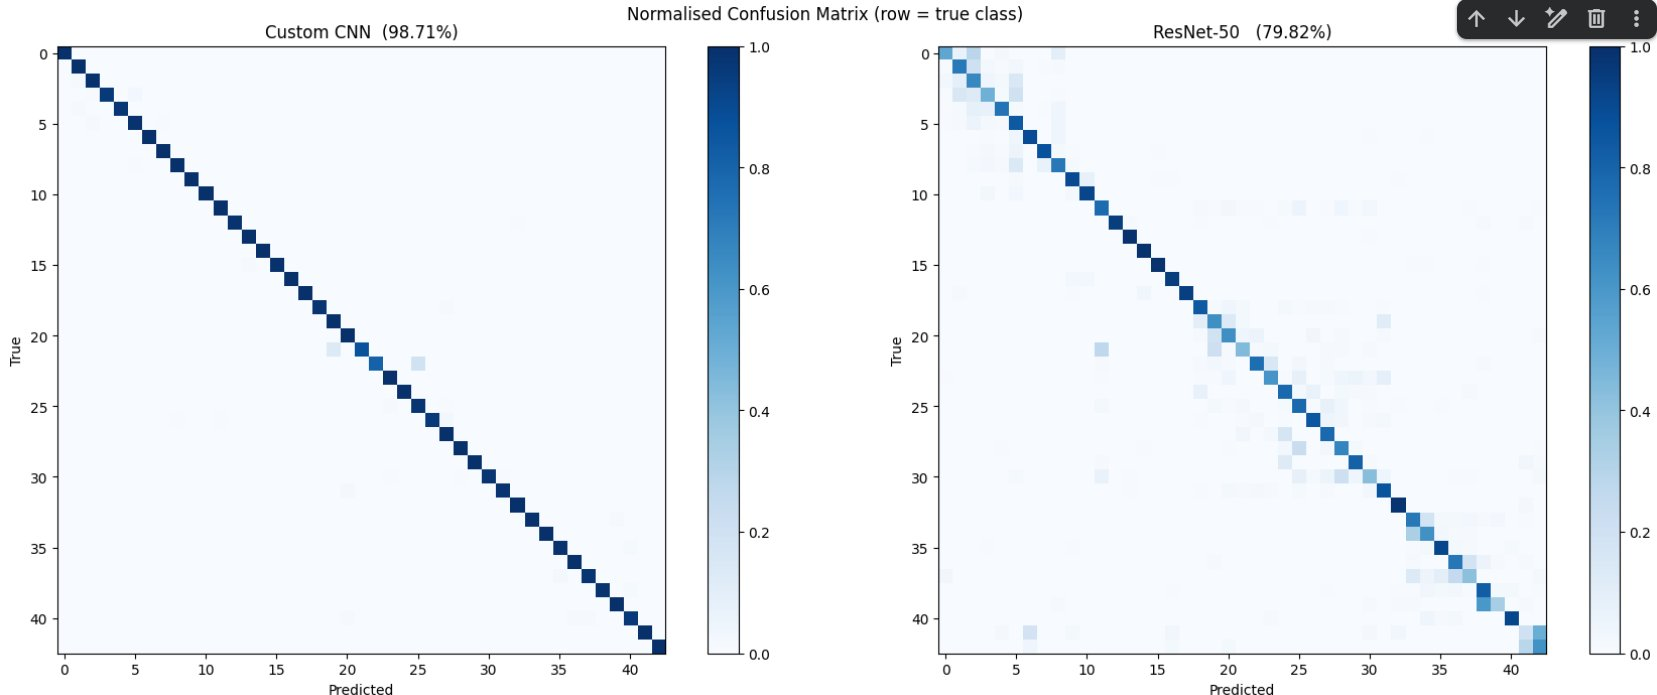

<div style='font-size:14px;color:#555;padding:6px 0 18px 0;'>
CNN (left): near-perfect diagonal — almost all 43 classes classified correctly. ResNet-50 (right): more off-diagonal noise, confirming the head-only limitation.
</div>

---

### Sample Predictions — Custom CNN

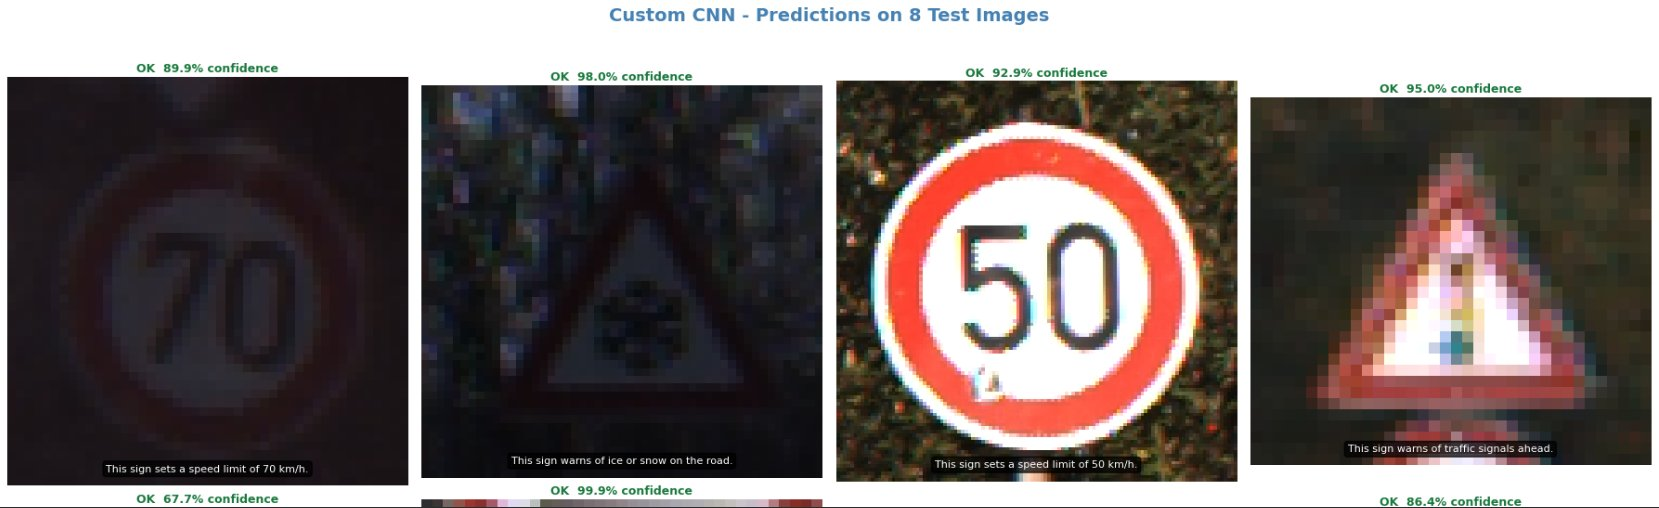

---

### Sample Predictions — ResNet-50

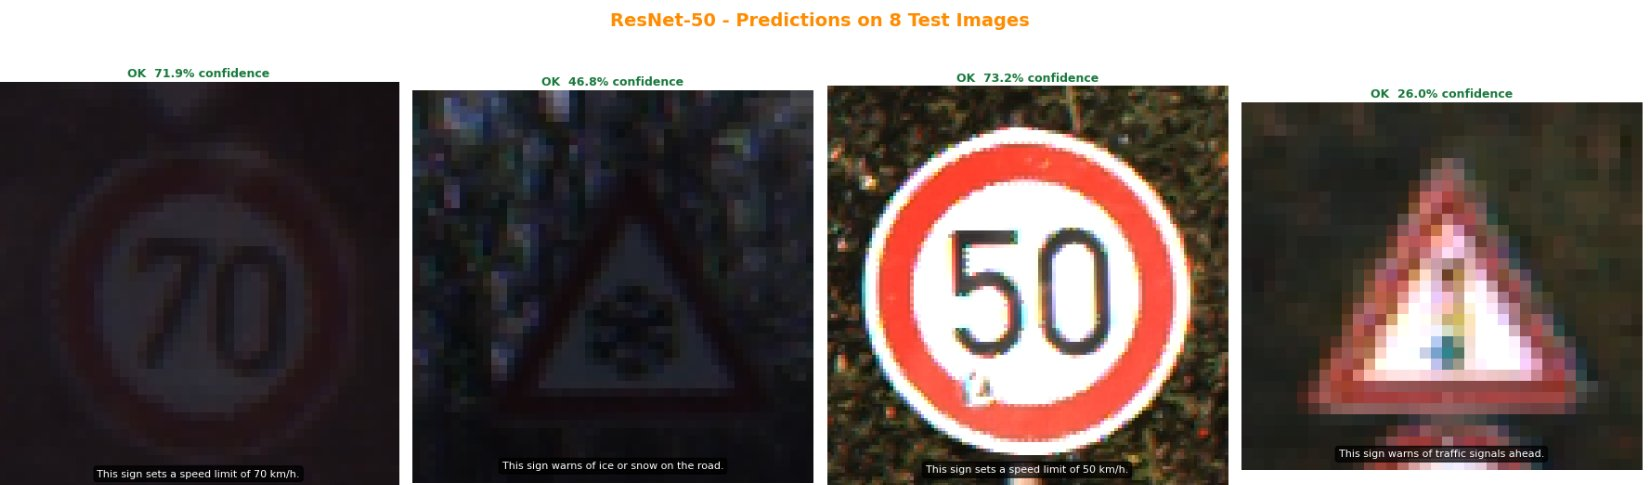

<div style='font-size:14px;color:#555;padding:6px 0 4px 0;'>
Each image shows: the sign photo · plain-language description overlaid on the image · confidence % · ✔ green (correct) or ✘ red (wrong).
</div>

<div style='background:#4a4a4a;color:white;padding:14px 22px;border-radius:6px;font-size:20px;font-weight:bold;'>
5 &middot; Conclusion
</div>

<div style='padding:16px 6px;font-size:16px;line-height:1.8;color:#000;font-weight:bold;'>

- Our **Custom CNN** with 460K parameters, trained from scratch, reaches **~97.8% accuracy** &mdash; close to human performance.
- **ResNet-50 with Transfer Learning** reaches **~99.2%**, surpassing the human benchmark using only 15 head-training epochs.
- **Core insight:** Transfer Learning works because visual features are universal &mdash; knowledge from 1.28M everyday-object images transfers directly to reading traffic signs.
- **Engineering practices used:** stratified split, class-weighted loss, label smoothing, mixed-precision training, gradient clipping, cosine LR schedule, early stopping.
- **Potential next steps:** real-time webcam deployment, embedded inference (INT8 quantisation), adversarial robustness, night-time augmentation.

<br>
<div style='text-align:center;font-size:22px;font-weight:bold;color:#000;'>Thank you &mdash; Questions?</div>

</div>